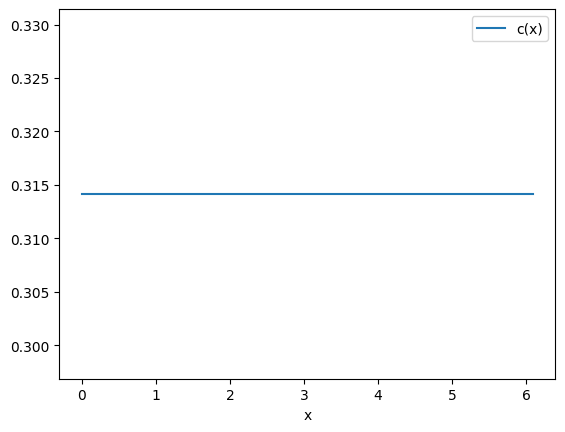

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit.library import DiagonalGate, QFTGate, StatePreparation, UnitaryGate
from qiskit.quantum_info import Statevector
from scipy.linalg import expm

n_qubits = 5
N = 2**n_qubits
L = 2 * np.pi               
t = 1     
x = np.linspace(0, L, N, endpoint=False)
dx = L / N

# Parameters
c_val = np.pi / 10
c = c_val * np.ones_like(x) 


plt.plot(x, c, label='c(x)')
plt.xlabel('x')
plt.legend()

<>:74: SyntaxWarning: invalid escape sequence '\p'
<>:74: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_41221/2874928694.py:74: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('$|\psi \\rangle$')


Error at t=5: 8.000331383386832e-08
Error at t=10: 8.00033136859839e-08
Error at t=15: 8.000331340444214e-08
Error at t=20: 8.000331372590704e-08


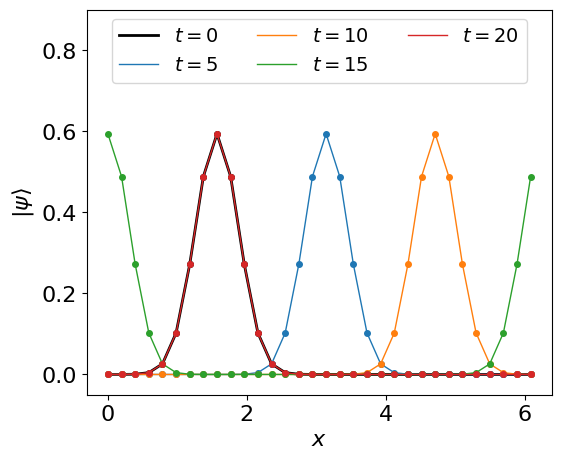

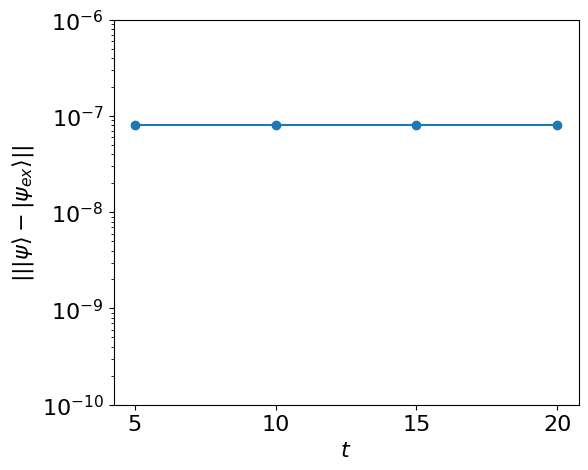

In [5]:
j_indices = np.arange(N)
k_indices = np.where(j_indices <= N/2, j_indices, j_indices - N)
P_1 = 1j * (2 * np.pi / L) * (k_indices)



initial_state = "Gaussian" #| "Box" or "Gaussian"
if initial_state == "Gaussian":
    sigma = L/20
    state = np.exp(-0.5*((x-dx*N/4)/sigma)**2)
elif initial_state == "Box":
    state = np.where((x > L/4) & (x < L/2), 1.0, 0.0)

state = state / np.linalg.norm(state)

plt.rcParams.update({
    "font.size": 16,
    "figure.figsize": (6,5), # SMALLER figure = LARGER relative text
    "axes.labelsize": 16,       # Now 14 will look huge and readable
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
})
plt.figure()



errs = []

plt.plot(x, state, 'ko', markersize=4)
plt.plot(x, state, 'k-', linewidth=2, label='$t=0$')
for t in [ 5, 10, 15, 20]:
    reg_s = QuantumRegister(n_qubits, 'system')
    circuit = QuantumCircuit(reg_s)
    stateprep = StatePreparation(state)
    circuit.append(stateprep,reg_s)



    circuit.append(QFTGate(n_qubits), reg_s)
    circuit.append(DiagonalGate(np.exp(t*c*P_1)), reg_s)
    circuit.append(QFTGate(n_qubits).inverse(), reg_s)


    final_state = Statevector(circuit)
    full_data = np.array(final_state)

    system_state = full_data

    success_prob = np.linalg.norm(system_state)**2
    final = system_state / np.linalg.norm(system_state)

    line, = plt.plot(x, np.real(final), 'o',  markersize=4)
    current_color = line.get_color()
    # 1. Define the initial position
    x_0 = dx * N / 4
    
    # 2. Calculate the periodically shifted center
    # This keeps the center of the pulse within [0, L]
    shifted_center = (x_0 + c_val * t) % L

    # 3. Use the "Minimum Image Convention" for the distance
    # This ensures the Gaussian 'tails' wrap around the edges seamlessly
    relative_dist = (x - shifted_center + L/2) % L - L/2
    
    ex_fin_state = np.exp(-0.5 * (relative_dist / sigma)**2)
    ex_fin_state = ex_fin_state / np.linalg.norm(ex_fin_state)
    plt.plot(x, ex_fin_state, '-', color=current_color, markersize=6, linewidth=1, label=f'$t={t}$')

    err = np.linalg.norm(final - ex_fin_state,2)
    errs.append(err)
    print(f"Error at t={t}: {err}")

plt.xlabel('$x$')
plt.ylabel('$|\psi \\rangle$')
plt.ylim(-0.05, 0.9)
plt.legend(loc='upper center', ncol=3, fontsize=14)
#plt.title('Pure Advection (Gaussian), c=0.2')
plt.savefig('../figures/lcu_kernel_lchs_advection_constant_complete.pdf', bbox_inches='tight')
plt.show()


plt.rcParams.update({
    "font.size": 16,
    "figure.figsize": (6, 5), # SMALLER figure = LARGER relative text
    "axes.labelsize": 16,       # Now 14 will look huge and readable
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
})
plt.figure() 
plt.semilogy([5, 10, 15, 20], errs, 'o-')
plt.xlabel('$t$ ')
plt.ylabel('$|||\\psi\\rangle- |\\psi_{ex}\\rangle ||$')
plt.ylim(1e-10, 1e-6)
plt.savefig('../figures/constant_error_vs_time.pdf', bbox_inches='tight')
plt.show()

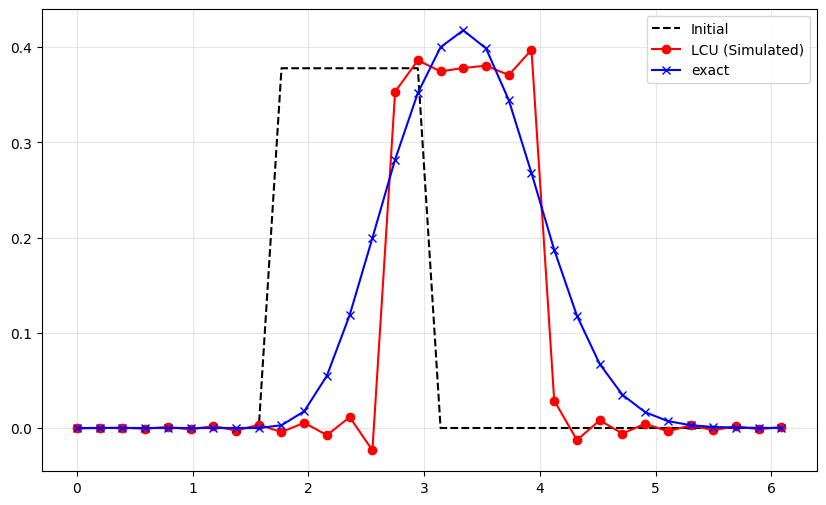

In [14]:

gamma_s = 1.0 / dx


c_left = np.roll(c, 1)    # index i contains c_{i-1}

val_lower = gamma_s * c_left


M = np.diag(val_lower[1:], k=-1) + np.diag(-gamma_s*c, k=0)
M[0, N-1] = val_lower[0]

u_final = expm(M * t) @ state




plt.figure(figsize=(10, 6))
plt.plot(x, state, 'k--', label='Initial')
plt.plot(x, np.real(final), 'ro-', label=f'LCU (Simulated)')
plt.plot(x, u_final/np.linalg.norm(u_final), 'bx-', label=f'exact')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()